In [1]:
import os
import sys
import argparse
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Attack'))

from BA import oh_binary_accuracy

from FGSM import FGSM_3V

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=5_000, help='Total # of samples') # 2_000 -> 5_000
parser.add_argument('--mb_size', type=int, default=32, help='Mini-batch size. See utils.py') # 64 -> 32; maybe 48?
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 48 -> 64; maybe 64
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=128, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=50, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=7e-05, help='Input learning rate for optimizer') # 1e-4 -> 7e-5 -> 5e-5
parser.add_argument('--max_epochs', type=int, default=500, help='Input max_epoch for cut-off') # 100 -> 300 -> 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [3]:
_, xtest, _, _ = get_mmcelebahq_dataloader(args=opt)

info 0 5000 1


/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebHQ-V3/data.py:31: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  label = torch.tensor(label, dtype=torch.double).T


info 5001 10001 1


In [4]:
model = torch.load('./out/Final.tar', weights_only=False)

net_im_en = model['net_im_en']
net_sk_en = model['net_sk_en']
net_la_en = model['net_la_en']
net_im_de = model['net_im_de']
net_sk_de = model['net_sk_de']
net_la_de = model['net_la_de']

net_im_en.eval()
net_sk_en.eval()
net_la_en.eval()
net_im_de.eval()
net_sk_de.eval()
net_la_de.eval()

NetLaDe(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=128, out_features=256, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (drop2): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=40, bias=True)
)

In [5]:
def kPCA(X, Y, Z, eps=1e-6):
    # Kernel matrix (B,B)
    # print('Shapes of KPCA input:', X.shape, Y.shape, Z.shape)

    a = (X @ X.T + Y @ Y.T + Z @ Z.T) / 3
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [6]:
def partial_kPCA(views, eps=1e-6, etas=None, normalize_missing=False):
    if len(views) == 0:
        raise ValueError("At least one view is required.")

    device = views[0].device
    dtype = views[0].dtype
    B = views[0].size(0)

    for v in views:
        if v.size(0) != B:
            raise ValueError("All views must have the same batch size.")

    if etas is None:
        etas = [1.0] * len(views)
    if len(etas) != len(views):
        raise ValueError("len(etas) must match len(views).")

    # Sum weighted Gram matrices
    a = torch.zeros(B, B, device=device, dtype=dtype)
    for v, eta in zip(views, etas):
        a = a + (v @ v.T) / eta

    # Optional: compensate for missing views by keeping scale comparable
    if normalize_missing:
        a = a / len(views)

    # Center
    oneN = torch.ones(B, B, device=device, dtype=dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Symmetrize + jitter
    a = 0.5 * (a + a.T)
    a = a + eps * torch.eye(B, device=device, dtype=dtype)

    # Eigendecomposition
    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    h = evecs[:, :h_dim]
    s = evals[:h_dim]

    return h, s

In [7]:
FGSM = FGSM_3V(net_im_en, net_sk_en, net_la_en, net_im_de, net_sk_de, net_la_de, kPCA, partial_kPCA, opt)

## Attack
### Clean Reconstruction

In [8]:
datax, datay, dataz = next(iter(xtest))
datax = datax.to(opt.device).double()
datay = datay.to(opt.device).double()
dataz = dataz.to(opt.device).double()

in_data_xtest = datax[:10].detach().cpu().numpy()
in_data_ytest = datay[:10].detach().cpu().numpy()
in_data_ztest = dataz[:10].detach().cpu().numpy()

with torch.no_grad():
    im_en = net_im_en(datax)
    sk_en = net_sk_en(datay)
    la_en = net_la_en(dataz)

    _h, _ = kPCA(im_en, sk_en, la_en)

    U = torch.mm(im_en.t(), _h)
    V = torch.mm(sk_en.t(), _h)
    W = torch.mm(la_en.t(), _h)

    x_tilde = net_im_de(torch.mm(_h, U.t()))
    y_tilde = net_sk_de(torch.mm(_h, V.t()))
    z_tilde = net_la_de(torch.mm(_h, W.t()))

out_data_xtest = x_tilde.detach().cpu().numpy()
out_data_ytest = y_tilde.detach().cpu().numpy()
out_data_ztest = z_tilde.detach().cpu().numpy()

### Attacked Reconstruction

In [9]:
epsilon = 0.1

fgsm_batch, _ = FGSM.create_adversarial_batch(datax, datay, dataz, epsilon=epsilon)
bim_batch, _ = FGSM.create_adversarial_batch_bim(datax, datay, dataz, epsilon=epsilon, alpha=0.1, num_iterations=10)

with torch.no_grad():
    fgsm_x_tilde, fgsm_y_tilde, fgsm_z_tilde = FGSM.run_model_batch(fgsm_batch, datay, dataz)
    bim_x_tilde, bim_y_tilde, bim_z_tilde = FGSM.run_model_batch(bim_batch, datay, dataz)

adv_data_xtest = fgsm_batch[:10].detach().cpu().numpy()
perturbations = (fgsm_batch - datax)[:10].detach().cpu().numpy()

fgsm_out_X = fgsm_x_tilde[:10].detach().cpu().numpy()
fgsm_out_Y = fgsm_y_tilde[:10].detach().cpu().numpy()
fgsm_out_Z = fgsm_z_tilde[:10].detach().cpu().numpy()

bim_out_X = bim_x_tilde[:10].detach().cpu().numpy()
bim_out_Y = bim_y_tilde[:10].detach().cpu().numpy()
bim_out_Z = bim_z_tilde[:10].detach().cpu().numpy()

### Reconstruction without image view

In [10]:
with torch.no_grad():
    fgsm_x_tilde_noim, fgsm_y_tilde_noim, fgsm_z_tilde_noim = FGSM.run_model_batch_noimview(datay, dataz)
    bim_x_tilde_noim, bim_y_tilde_noim, bim_z_tilde_noim = FGSM.run_model_batch_noimview(datay, dataz)

fgsm_noim_out_X = fgsm_x_tilde_noim[:10].detach().cpu().numpy()
fgsm_noim_out_Y = fgsm_y_tilde_noim[:10].detach().cpu().numpy()
fgsm_noim_out_Z = fgsm_z_tilde_noim[:10].detach().cpu().numpy()

bim_noim_out_X = bim_x_tilde_noim[:10].detach().cpu().numpy()
bim_noim_out_Y = bim_y_tilde_noim[:10].detach().cpu().numpy()
bim_noim_out_Z = bim_z_tilde_noim[:10].detach().cpu().numpy()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x32 and 256x49152)

### Loss Calculation

In [ ]:
recon_loss = torch.nn.MSELoss()
label_recon_loss = torch.nn.BCEWithLogitsLoss()
B = datax.size(0)

#! Clean batch losses
clean_digit_loss = recon_loss(x_tilde.view(B, -1), datax.view(B, -1))
clean_sketch_loss = recon_loss(y_tilde.view(B, -1), datay.view(B, -1))
clean_label_loss = label_recon_loss(
    torch.as_tensor(out_data_ztest, device=dataz.device).reshape(B, -1).float(),
    dataz.reshape(B, -1).float()
)

clean_total_loss = (clean_digit_loss + clean_sketch_loss + clean_label_loss) / 3

#! FGSM batch losses
fgsm_digit_loss = recon_loss(fgsm_x_tilde.view(B, -1), datax.view(B, -1))
fgsm_sketch_loss = recon_loss(fgsm_y_tilde.view(B, -1), datay.view(B, -1))
fgsm_label_loss = label_recon_loss(
    fgsm_z_tilde.view(B, -1),
    dataz.reshape(B, -1).float()
)

fgsm_total_loss = (fgsm_digit_loss + clean_sketch_loss + fgsm_label_loss) / 3

#! BIM batch losses
bim_digit_loss = recon_loss(bim_x_tilde.view(B, -1), datax.view(B, -1))
bim_sketch_loss = recon_loss(bim_y_tilde.view(B, -1), datay.view(B, -1))
bim_label_loss = label_recon_loss(
    bim_z_tilde.view(B, -1),
    dataz.reshape(B, -1).float()
)

bim_total_loss = (bim_digit_loss + clean_sketch_loss + bim_label_loss) / 3

### Plotting

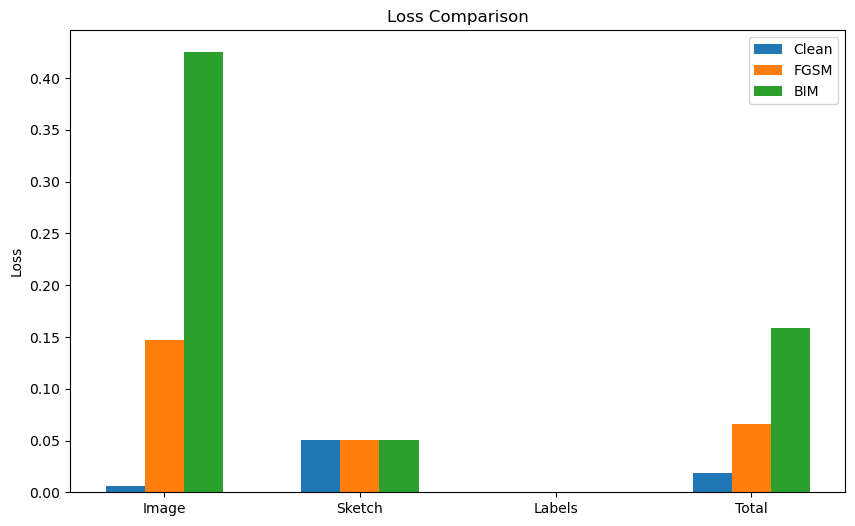

In [ ]:
cat = ['Image', 'Sketch', 'Labels', 'Total']
clean_losses = [clean_digit_loss.item(), clean_sketch_loss.item(), clean_label_loss.item(), clean_total_loss.item()]
fgsm_losses = [fgsm_digit_loss.item(), fgsm_sketch_loss.item(), fgsm_label_loss.item(), fgsm_total_loss.item()]
bim_losses = [bim_digit_loss.item(), bim_sketch_loss.item(), bim_label_loss.item(), bim_total_loss.item()]

x = list(range(len(cat)))

plt.figure(figsize=(10, 6))
plt.bar(x, clean_losses, width=0.2, label='Clean', align='center')
plt.bar([i + 0.2 for i in x], fgsm_losses, width=0.2, label='FGSM', align='center')
plt.bar([i + 0.4 for i in x], bim_losses, width=0.2, label='BIM', align='center')
plt.xticks([i + 0.2 for i in x], cat)
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.show()

In [ ]:
def plot_label_bars(ax, top_array, bottom_array, true_color='tab:blue', false_color='white'):
    top = np.array(top_array)
    bottom = np.array(bottom_array)

    if hasattr(top, "detach"):
        top = top.detach().cpu().numpy()
    if hasattr(bottom, "detach"):
        bottom = bottom.detach().cpu().numpy()

    top = top.squeeze().astype(bool)
    bottom = (bottom.squeeze() > 0.5)

    bar_img = np.vstack([top.astype(int), bottom.astype(int)])

    cmap = ListedColormap([false_color, true_color])
    ax.imshow(bar_img, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=1)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Labels', 'Generated Labels\n> 0.5'], fontsize=10)
    ax.set_xticks(np.arange(len(top)))
    ax.set_xticklabels(np.arange(len(top)), fontsize=8, rotation=90)
    ax.set_xlim(-0.5, len(top) - 0.5)

    # draw grid between bars
    ax.set_xticks(np.arange(-0.5, len(top), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_52472/3336117864.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  top = np.array(top_array)
/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_52472/3336117864.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  top = np.array(top_array)
/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_52472/3336117864.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing c

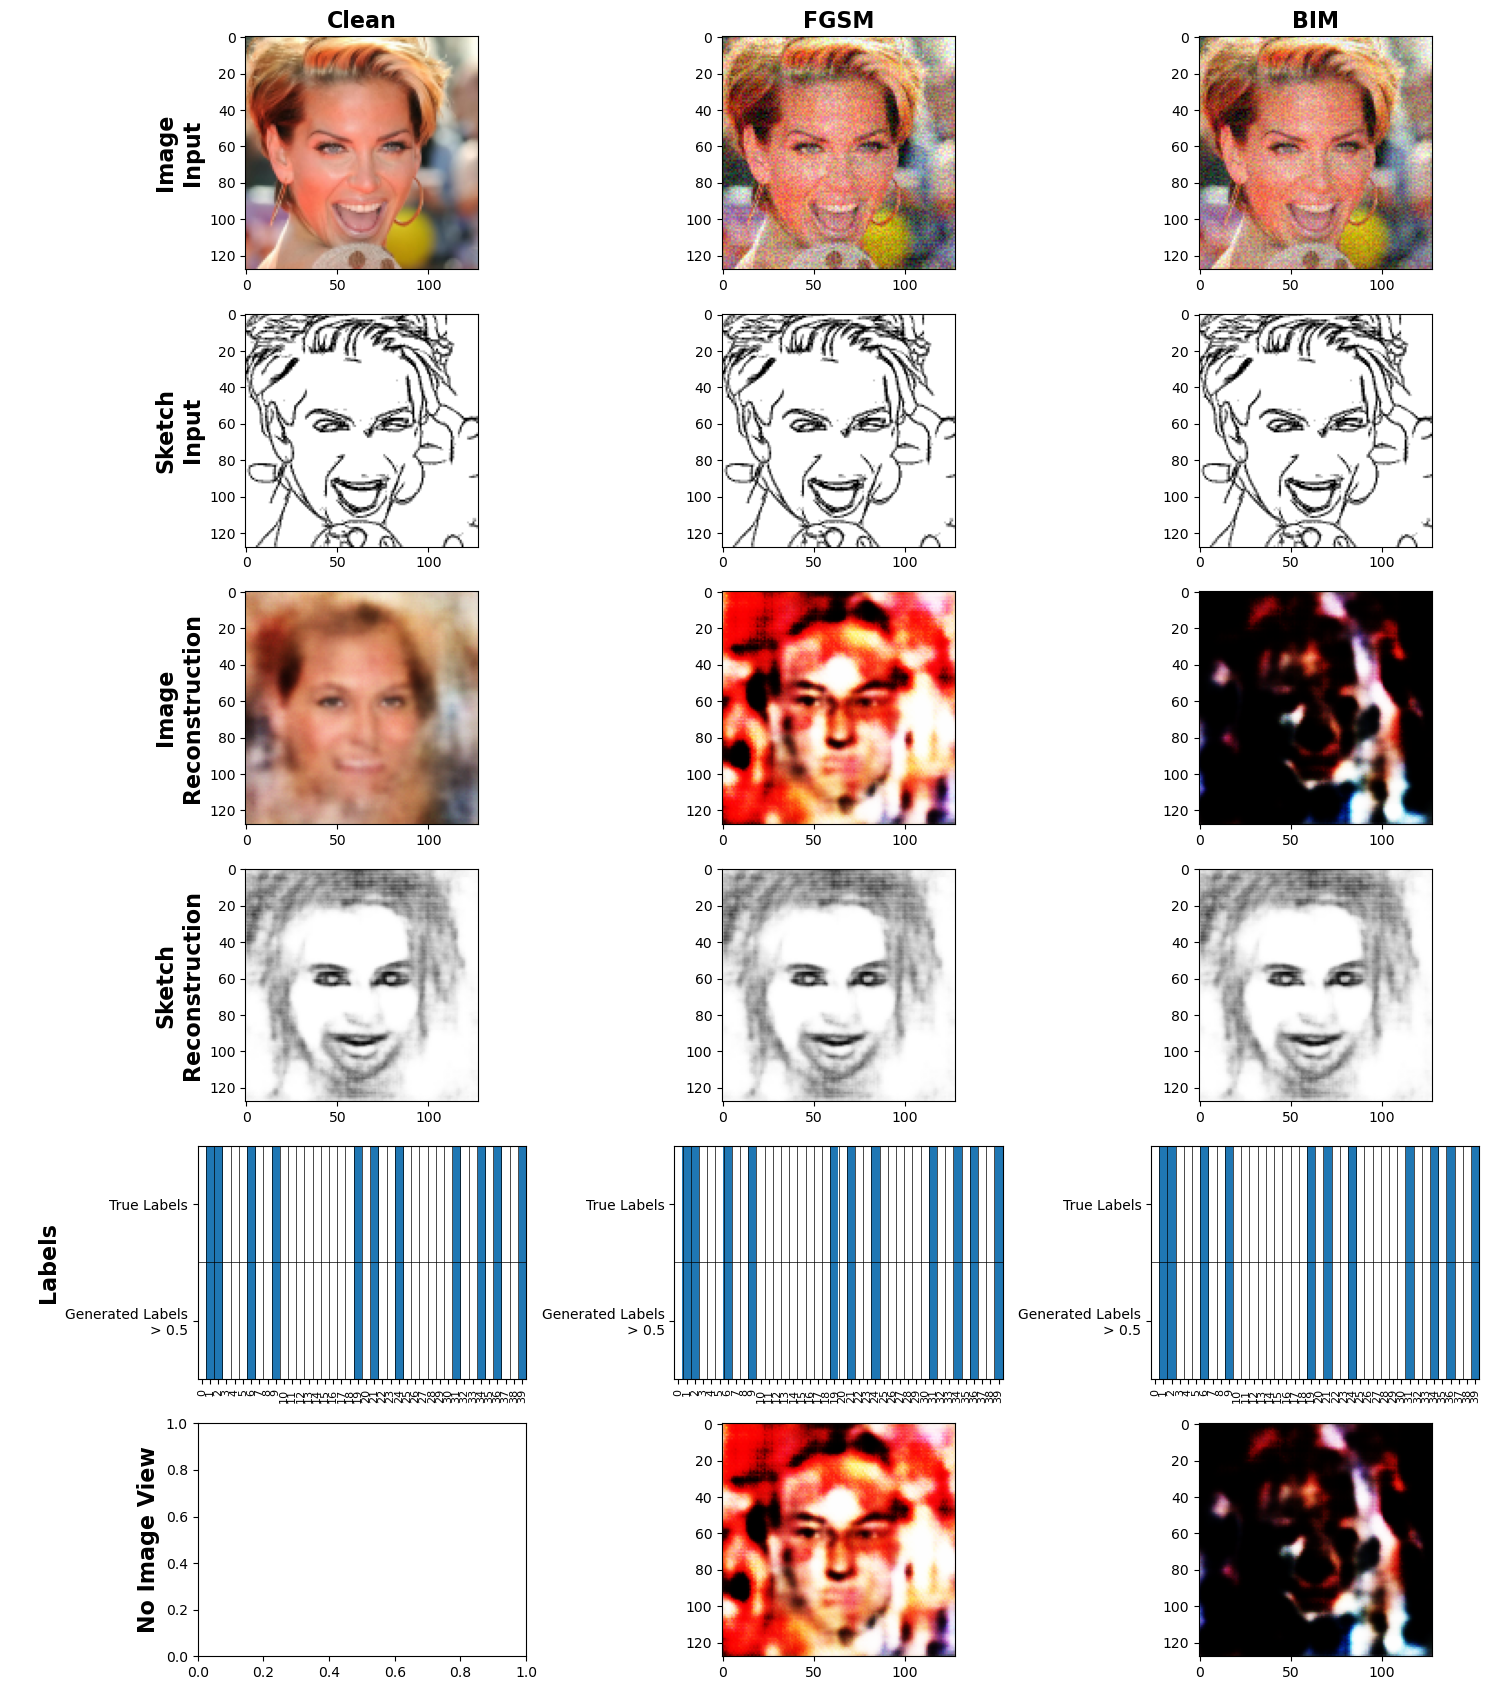

In [ ]:
fig, axes = plt.subplots(6, 3, figsize=(15, 17))

axes[0, 0].set_ylabel('Image\nInput', fontsize=16, fontweight='bold')
axes[1, 0].set_ylabel('Sketch\nInput', fontsize=16, fontweight='bold')
axes[2, 0].set_ylabel('Image\nReconstruction', fontsize=16, fontweight='bold')
axes[3, 0].set_ylabel('Sketch\nReconstruction', fontsize=16, fontweight='bold')
axes[4, 0].set_ylabel('\nLabels', fontsize=16, fontweight='bold')
axes[5, 0].set_ylabel('\nNo Image View', fontsize=16, fontweight='bold')

axes[0, 0].set_title('Clean', fontsize=16, fontweight='bold')
axes[0, 0].imshow(in_data_xtest[0].transpose(1, 2, 0).reshape(128, 128, 3))
axes[1, 0].imshow(in_data_ytest[0].reshape(128, 128, 1), cmap='gray')
axes[2, 0].imshow(out_data_xtest[0].transpose(1, 2, 0).reshape(128, 128, 3))
axes[3, 0].imshow(out_data_ytest[0].transpose(1, 2, 0).reshape(128, 128, 1), cmap='gray')

axes[0, 1].set_title('FGSM', fontsize=16, fontweight='bold')
axes[0, 1].imshow(fgsm_batch[0].detach().cpu().numpy().transpose(1, 2, 0).reshape(128, 128, 3))
axes[1, 1].imshow(datay[0].detach().cpu().numpy().reshape(128, 128, 1), cmap='gray')
axes[2, 1].imshow(fgsm_out_X[0].transpose(1, 2, 0).reshape(128, 128, 3))
axes[3, 1].imshow(fgsm_out_Y[0].transpose(1, 2, 0).reshape(128, 128, 1), cmap='gray')
axes[5, 1].imshow(fgsm_noim_out_X[0].transpose(1, 2, 0).reshape(128, 128, 3))

axes[0, 2].set_title('BIM', fontsize=16, fontweight='bold')
axes[0, 2].imshow(bim_batch[0].detach().cpu().numpy().transpose(1, 2, 0).reshape(128, 128, 3))
axes[1, 2].imshow(datay[0].detach().cpu().numpy().reshape(128, 128, 1), cmap='gray')
axes[2, 2].imshow(bim_out_X[0].transpose(1, 2, 0).reshape(128, 128, 3))
axes[3, 2].imshow(bim_out_Y[0].transpose(1, 2, 0).reshape(128, 128, 1), cmap='gray')
axes[5, 2].imshow(bim_noim_out_X[0].transpose(1, 2, 0).reshape(128, 128, 3))

plot_label_bars(axes[4, 0], dataz[0], out_data_ztest[0])
plot_label_bars(axes[4, 1], dataz[0], fgsm_out_Z[0])
plot_label_bars(axes[4, 2], dataz[0], bim_out_Z[0])

plt.tight_layout()
plt.show()